In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']

In [3]:
token = '2712985633675e074d63da9266dba7714d932b8e447f0f4632ca0965701237c6fb67854d65b3457cf7087e056cda6859748c77bd7721251cdaf17e9a1e30e6cc'
provider = qiskit_ibm_provider.IBMProvider(token)
instance = 'ibm-q/open/main'
device = 'sherbrooke'
backend_name = 'ibm_'+device # get_backend_name(device)
backend = provider.get_backend(backend_name, instance=instance)
n_qubits = backend.configuration().n_qubits
qubits = np.arange(n_qubits)
scan_backend(token, provider, device)
colors_gradient = get_color_gradient('#0000FF', '#FF0000', n_qubits)

(no-q) Device: sherbrooke
q = 0: T1 = 307us, T2 = 224us
q = 1: T1 = 308us, T2 = 312us
q = 2: T1 = 205us, T2 = 158us
q = 3: T1 = 441us, T2 = 221us
q = 4: T1 = 377us, T2 = 415us
q = 5: T1 = 260us, T2 = 298us
q = 6: T1 = 283us, T2 = 427us
q = 7: T1 = 286us, T2 = 271us
q = 8: T1 = 423us, T2 = 301us
q = 9: T1 = 287us, T2 = 69us
q = 10: T1 = 216us, T2 = 180us
q = 11: T1 = 470us, T2 = 98us
q = 12: T1 = 403us, T2 = 277us
q = 13: T1 = 350us, T2 = 166us
q = 14: T1 = 258us, T2 = 156us
q = 15: T1 = 403us, T2 = 306us
q = 16: T1 = 337us, T2 = 165us
q = 17: T1 = 234us, T2 = 78us
q = 18: T1 = 243us, T2 = 57us
q = 19: T1 = 461us, T2 = 132us
q = 20: T1 = 504us, T2 = 89us
q = 21: T1 = 442us, T2 = 25us
q = 22: T1 = 132us, T2 = 168us
q = 23: T1 = 147us, T2 = 204us
q = 24: T1 = 273us, T2 = 182us
q = 25: T1 = 275us, T2 = 484us
q = 26: T1 = 313us, T2 = 210us
q = 27: T1 = 311us, T2 = 122us
q = 28: T1 = 224us, T2 = 63us
q = 29: T1 = 399us, T2 = 191us
q = 30: T1 = 374us, T2 = 256us
q = 31: T1 = 234us, T2 = 32us


In [4]:
nc = noise_characterization(backend, 0, m_FTTPS=6, num_T1=20, num_T2=20)
dt = 0.03555

# Simulations

In [5]:
import scipy

paulis = [pauli_x, pauli_y, pauli_z]
rho_0 = np.array([[1,0],[0,0]])
v0 = np.array([0,0,1])

rho2bloch = lambda rho: np.array([np.trace(rho@pauli) for pauli in paulis])

def Gmat(theta, alpha, mu, eta, beta, eps, dt):
    return np.array([[-alpha, -beta, 0],
                     [beta, -mu , -theta*(1+eps)/dt],
                     [0,theta*(1+eps)/dt, -eta]])

rb_fun = lambda t,s,c: (1+(1-2*s)*np.exp(-t*c))/2

ns = noisy_simulation(backend, 0)

In [6]:
def sim_exact(circ, spam, gamma, q, beta, lmbda, eps, nu, verbose=0):
    t_circ = qk.compiler.transpile(circ, backend=backend, basis_gates=['id','x','rz','sx'], 
                                         initial_layout=[0], optimization_level=0)

    alpha = gamma/2 + lmbda
    mu = alpha + nu
    eta = gamma + nu
    
    # c vector
    c = np.array([0,0,gamma*(2*q-1)])
    # π gate
    G_pi    = Gmat(np.pi, alpha, mu, eta, beta/1.5, eps, dt)
    Ginv_pi = scipy.linalg.inv(G_pi)
    eGt_pi  = scipy.linalg.expm(G_pi*dt)
    # π/2 gate
    G_pi2    = Gmat(np.pi/2, alpha, mu, eta, beta/1.5, eps, dt)
    Ginv_pi2 = scipy.linalg.inv(G_pi2)
    eGt_pi2  = scipy.linalg.expm(G_pi2*dt)
    # Identity
    G_0    = Gmat(0, alpha, alpha, gamma, beta, eps, dt)
    Ginv_0 = scipy.linalg.inv(G_0)
    eGt_0  = scipy.linalg.expm(G_0*dt)
    
    vt = [np.real(v0)]
    for Cinst in t_circ:
        instruction = Cinst[0]
        name = instruction.name
        if name=='rz':
            new_vt = ns.bloch_update_rz(vt[-1], theta=float(instruction.params[0]))     
        elif name=='x':
            new_vt = eGt_pi@vt[-1] + (eGt_pi-np.identity(3))@Ginv_pi@c
        elif name=='sx':
            new_vt = eGt_pi2@vt[-1] + (eGt_pi2-np.identity(3))@Ginv_pi2@c
        elif name=='id':
            new_vt = eGt_0@vt[-1] + (eGt_0-np.identity(3))@Ginv_0@c
        elif name=='barrier' or name=='measure':
            if verbose>0: print(name)
            continue
        else:
            print("unknown gate/instruction:", instruction)
            return 0
        vt.append( list(np.real(np.around(new_vt, 6)) ) )

    rho_t = (Id + vt[-1][0]*pauli_x + vt[-1][1]*pauli_y + vt[-1][2]*pauli_z)/2
    if spam: rho_t = (1-spam)*rho_t + spam*pauli_x@rho_t@pauli_x 
    ps = np.real(np.trace(rho_t @ rho_0))
    return ps

# PAPER FIG

In [8]:
nc.rb_lens = [8,  16,  32,  64, 128, 256, 512, 1024]
nc.nseeds  = 10
nc.RB_circs = nc.generate_RB_circs()

RB (max length, nseeds): (1024, 10)


In [9]:
RB_circs = np.reshape(nc.RB_circs,(len(nc.rb_lens),nc.nseeds))
rb_gate_lens = np.array([[str(circ).count('X') + str(circ).count('H') + 2*str(circ).count('Y') for circ in circs] for circs in RB_circs])
rb_gate_lens_mean = np.mean(rb_gate_lens,axis=1)

C:\Users\14432\Anaconda3\envs\mezze_env\lib\site-packages\numpy\core\fromnumeric.py:43: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = getattr(asarray(obj), method)(*args, **kwds)


In [10]:
circuits_rb = {}
for k,circ in enumerate(nc.RB_circs):
    circ.append(cirq.measure(cirq.GridQubit(0,0)))
    circuits_rb[k] = cirq2qiskit(circ)

In [31]:
x_rb_mean = rb_gate_lens_mean/1.8
exp_fun = lambda t,s,r: (1+(1-2*s)*np.exp(-t*r))/2
x_rb_mean_fine = np.linspace(x_rb_mean[0],x_rb_mean[-1],100)

In [28]:
weak_noise_params = {'beta': 0.002/dt,
                    'epsilon': 0.001,
                    'gamma': 0.001/dt,
                    'lambda': 0.001/dt,
                    'nu':    0.001/dt}
strong_noise_params = {'beta': 0.02/dt,
                    'epsilon':   0.02,
                    'gamma': 0.01/dt,
                    'lambda': 0.02/dt,
                    'nu':    0.005/dt}
param_labels = ['beta','epsilon','gamma','lambda','nu']

In [29]:
# Simulations
ps_sims_random = {}

for i,label in enumerate(param_labels):
    print(label)
    beta, epsilon, gamma, lmbda, nu = weak_noise_params.values()
    if label=='beta':
        beta = strong_noise_params['beta']
    elif label=='epsilon':
        epsilon = strong_noise_params['epsilon']
    elif label=='gamma':
        gamma = strong_noise_params['gamma']
    elif label=='lambda':
        lmbda = strong_noise_params['lambda']
    elif label=='nu':
        nu = strong_noise_params['nu']
        
    ps_sims = [sim_exact(circuits_rb[idx], 0, gamma, 1, beta, lmbda, epsilon, nu) 
                               for idx in range(nc.nseeds*len(nc.rb_lens))]
    ps_sims_random[i] = np.reshape(ps_sims,(len(nc.rb_lens),nc.nseeds))

beta
epsilon
gamma
lambda
nu


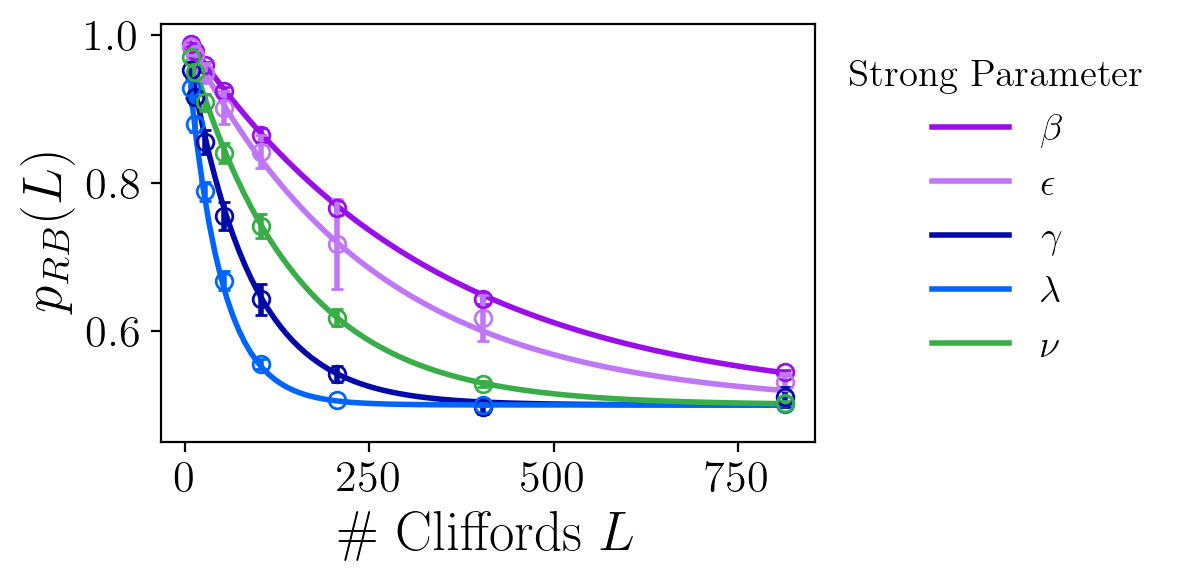

In [38]:
fig = plt.figure(dpi=200, figsize=(6,3))

for i,label in enumerate(param_labels):
    beta, epsilon, gamma, lmbda, nu = weak_noise_params.values()
    if label=='beta':
        beta = strong_noise_params['beta']
    elif label=='epsilon':
        epsilon = strong_noise_params['epsilon']
    elif label=='gamma':
        gamma = strong_noise_params['gamma']
    elif label=='lambda':
        lmbda = strong_noise_params['lambda']
    elif label=='nu':
        nu = strong_noise_params['nu']
        
    ps  = np.mean(ps_sims_random[i], axis=1)
    dps = np.std(ps_sims_random[i], axis=1)
    
    plt.errorbar(x_rb_mean, ps, dps, lw=0, marker='o', mfc='None', color=colors_greg[i], capsize=2, elinewidth=2)
    
    ps_i = (1+np.exp(-dt*x_rb_mean_fine*(gamma+lmbda+nu)-(np.pi/2*epsilon)**2*x_rb_mean_fine))/2
    plt.plot(x_rb_mean_fine, ps_i, lw=2, ls='-', color=colors_greg[i], label='$\%s$'%param_labels[i])
    
plt.ylabel(r'$p_{RB}(L)$',size=20)
plt.xlabel('\# Cliffords $L$',size=20)
plt.tick_params(axis='both', which='major', labelsize=16)

# plt.errorbar(x_rb_mean, ps*0, dps*0, lw=0, marker='.', mfc='None', color='k', capsize=2, elinewidth=2, label='Simulation')
# plt.plot(0,0, color='k', label='Prediction')

plt.ylim(bottom=0.45)
plt.legend(frameon=False, fontsize=14, title=r'Strong Parameter', 
           title_fontsize=14, bbox_to_anchor=(1,1) )
plt.tight_layout()
plt.savefig('figures/RB_markov.pdf')
plt.show()

In [37]:
strong_noise_params

{'beta': 0.5625879043600563,
 'epsilon': 0.02,
 'gamma': 0.2812939521800282,
 'lambda': 0.5625879043600563,
 'nu': 0.1406469760900141}